In [1]:
from langgraph.graph import StateGraph, START,END
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from typing import TypedDict, Literal, Annotated
from langchain.messages import SystemMessage,HumanMessage
import operator
from dotenv import load_dotenv
load_dotenv()

d:\AI\VS CODE\Langchain\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [3]:
gen_llm=ChatOpenAI(model='gpt-5-mini')
eval_llm=ChatOpenAI(model='gpt-5-mini')
opt_llm=ChatOpenAI(model='gpt-5-mini')

In [4]:
class schema(BaseModel):
    feedback:str=Field(description='return the feedback')
    evaluation:Literal['approved', 'needs_improvement']=Field(description='return the evaluation of the post')

str_model=eval_llm.with_structured_output(schema)


In [5]:
class linkstate(TypedDict):
    topic:str
    post:str
    evaluation:Literal['approved', 'needs_improvement']
    feedback:str
    iteration:int
    max_iteration:int

In [6]:
def generator(state: linkstate) -> linkstate:
    topic=state['topic']
    mssg=[
        SystemMessage(content=f""" You are an expert LinkedIn content creator specializing in AI, technology, career growth, software engineering, and startup content.

Your job is to create a high-quality LinkedIn post designed for strong organic engagement.

Write like an experienced human professional, not like an AI assistant.

Prioritize:

A strong first-line hook that makes people want to continue reading.
One clear central idea.
Short, easy-to-scan paragraphs.
Specific insights, examples, experiences, or observations.
Natural and conversational language.
Useful information rather than generic motivational statements.
A clear emotional or intellectual payoff.
A closing that encourages genuine discussion.

Avoid:

Generic AI phrases such as "In today's rapidly evolving world."
Excessive emojis.
Clickbait that does not deliver value.
Overly formal language.
Unnecessary headings.
Repeating the same idea.
Fake personal experiences or unsupported claims.
Promising that the post will "go viral."

The post should feel authentic and written by a knowledgeable professional.

Do not explain your writing process. Return only the LinkedIn post. """),
HumanMessage(content=f""" Create a LinkedIn post based on the following information:Topic: {topic} """)
    ]
    rs=gen_llm.invoke(mssg)
    return {'post':rs.content}


In [7]:
def evaluator(state: linkstate)-> linkstate:
  post=state['post']

  mssg=[SystemMessage(content=""" You are a strict LinkedIn content evaluator.

Your job is to evaluate a LinkedIn post for its potential to
generate genuine engagement and provide useful feedback to an
optimizer.

DO NOT rewrite the post.

DO NOT generate an alternative post.

DO NOT modify the original content.

Evaluate the post using the following criteria:

1. Hook
   - Is the first 1-2 lines strong enough to stop scrolling?
   - Does it create curiosity?

2. Clarity
   - Is the main idea immediately understandable?

3. Value
   - Does the reader learn something useful, interesting, or actionable?

4. Specificity
   - Does the post contain concrete examples, observations,
     experiences, numbers, or insights?

5. Authenticity
   - Does it sound human and credible?
   - Does it feel AI-generated or generic?

6. Structure
   - Is the post easy to scan?
   - Are paragraphs appropriately short?

7. Storytelling
   - Is there a logical progression?
   - Does the post maintain attention?

8. Engagement
   - Does the ending naturally encourage meaningful discussion?

9. Conciseness
   - Is there unnecessary repetition or filler?

10. Overall Engagement Potential
    - How strong is the post as a LinkedIn post?


Be critical.

Focus on the biggest weaknesses rather than giving unnecessary praise.

DO NOT rewrite any part of the post.

DO NOT suggest an entirely new post.

Return ONLY the evaluation and feedback.
"""),HumanMessage(content=f""" Evaluate the following LinkedIn post.

POST:
{post}

Evaluate the post according to all the criteria
defined in your system instructions.

Pay special attention to:

- Strength of the hook
- Value provided to the reader
- Specificity
- Authenticity
- Whether it sounds AI-generated
- Readability
- Storytelling
- Engagement potential
- Strength of the ending

Return only the evaluation and feedback.""")]
  rs=str_model.invoke(mssg)
  return {'evaluation':rs.evaluation, 'feedback':rs.feedback,'feedback_history':[rs.feedback] }

In [8]:
def optimizer(state: linkstate)-> linkstate:
  post=state['post']
  fd=state['feedback']
  mssg=[SystemMessage(content=""" You are an expert LinkedIn content editor and optimizer.

Your task is to improve an existing LinkedIn post using feedback
from a LinkedIn content evaluator.

Preserve:

- The original core idea.
- The original factual meaning.
- The intended audience.
- The author's voice.
- Any valid personal context.

Improve:

- The opening hook.
- Curiosity.
- Clarity.
- Specificity.
- Value.
- Flow.
- Readability.
- Authenticity.
- Engagement.
- The final takeaway.

Use the evaluator's highest-priority feedback first.

Do NOT:

- Invent facts.
- Invent personal experiences.
- Make unsupported claims.
- Use manipulative clickbait.
- Add excessive emojis.
- Add unnecessary hashtags.
- Change the central idea.
- Mention the evaluator.
- Mention the optimization process.
- Explain what you changed.

The goal is NOT to make the post sound more "AI polished."

The goal is to make it sound MORE HUMAN, SPECIFIC,
INTERESTING, and VALUABLE.

Return ONLY the final improved LinkedIn post."""), HumanMessage(content=f"""Improve the following LinkedIn post using the evaluator's feedback.

ORIGINAL POST:
{post}

EVALUATOR FEEDBACK:
{fd}


Important:

Preserve the original idea and factual meaning.

Focus primarily on the evaluator's highest-priority weaknesses.

Do not completely rewrite the post unless necessary.

Return ONLY the final improved LinkedIn post.""")]
  rs=opt_llm.invoke(mssg)
  iteration=state['iteration'] + 1
  return {'post':rs.content, 'iteration':iteration}


In [ ]:
def check(state:linkstate):
  if state['evaluation'] == 'approved':
    return 'approved'
  else:
    return 'needs_improvement'

In [ ]:
graph=StateGraph(linkstate)

graph.add_node('generator', generator)
graph.add_node('evaluator', evaluator)
graph.add_node('optimizer', optimizer)

graph.add_edge(START, 'generator')
graph.add_edge('generator', 'evaluator')
graph.add_conditional_edges('evaluator', check, {'approved':END, 'needs_improvement':'optimizer'})
graph.add_edge('optimizer','evaluator')

wf=graph.compile()

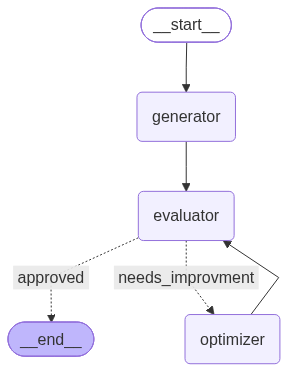

In [11]:
wf

In [14]:
rs=wf.invoke({'topic':'Langchain', 'iteration':1, 'max_iteration':5})


In [18]:
rs['post']

'Want to turn an LLM into a reliable product? LangChain is the glue—and when used intentionally it cuts weeks of engineering work. Used poorly it becomes technical debt. Here’s a practical playbook you can use tomorrow.\n\nLangChain’s value: it breaks an LLM app into composable pieces—document loaders, chunking, embeddings, retrievers/vector DBs, chains, agents, memory, and tools. Treat those as patterns, not magic.\n\nHow I break problems down (RAG-first mindset)\n- Ingest: use a document loader (PDFs, Notion, Google Drive). Don’t dump whole files into the model.\n- Chunk: 500–1,000 tokens with 50–100 token overlap is a good starting point. Smaller chunks = better pinpointed retrieval, but more vectors and cost.\n- Embed: pick an embedding model with similar domain performance to your LLM. Faster cheaper embeddings for frequent updates, higher-quality for small corpora.\n- Vector DB: Chroma, Pinecone, Milvus, Weaviate — they’re tradeoffs (local testing vs managed ops). Choose by scale